In [13]:
# ===============================
# 1. Import Libraries
# ===============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ===============================
# 2. Dataset Preparation
# ===============================
data_root = '/content/Dataset/data/Recognition'  # Adjust if needed
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')
test_dir  = os.path.join(data_root, 'test')

image_size = (256, 256)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=True, seed=seed
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False, seed=seed
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 26097 files belonging to 9 classes.
Found 1634 files belonging to 9 classes.
Found 1144 files belonging to 9 classes.
Classes: ['1000_taka', '100_taka', '10_taka', '200_taka', '20_taka', '2_taka', '500_taka', '50_taka', '5_taka']


In [14]:
# ===============================
# 3. Define MobileNetV2 Model
# ===============================
def create_mobilenetv2_model(input_shape=(256,256,3), num_classes=9):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # freeze backbone initially

    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='mobilenetv2_currency_classifier')
    return model

# Build model
model = create_mobilenetv2_model(input_shape=(image_size[0], image_size[1], 3), num_classes=num_classes)
model.summary()

/tmp/ipython-input-3093817700.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_currency_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# ===============================
# 4. Compile & Callbacks
# ===============================
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_path = "best_mobilenetv2_currency.h5"
callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

In [16]:
# ===============================
# 5. Train Model
# ===============================
epochs = 30
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

model.save("MobileNetV2_Bangla_Currency_Recognition_Cropped.h5")

Epoch 1/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4373 - loss: 1.6241
Epoch 1: val_loss improved from inf to 0.52041, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - accuracy: 0.4375 - loss: 1.6236 - val_accuracy: 0.8733 - val_loss: 0.5204 - learning_rate: 1.0000e-04
Epoch 2/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8076 - loss: 0.6304
Epoch 2: val_loss improved from 0.52041 to 0.31753, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.8076 - loss: 0.6303 - val_accuracy: 0.9211 - val_loss: 0.3175 - learning_rate: 1.0000e-04
Epoch 3/30
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8668 - loss: 0.4374
Epoch 3: val_loss improved from 0.31753 to 0.24142, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.8668 - loss: 0.4373 - val_accuracy: 0.9351 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 4/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9002 - loss: 0.3298
Epoch 4: val_loss improved from 0.24142 to 0.19511, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9002 - loss: 0.3298 - val_accuracy: 0.9443 - val_loss: 0.1951 - learning_rate: 1.0000e-04
Epoch 5/30
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9199 - loss: 0.2708
Epoch 5: val_loss improved from 0.19511 to 0.16806, saving model to best_mobilenetv2_currency.h5


...

816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9915 - loss: 0.0401 - val_accuracy: 0.9774 - val_loss: 0.0685 - learning_rate: 1.0000e-04
Epoch 21/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9924 - loss: 0.0368
Epoch 21: val_loss improved from 0.06847 to 0.06816, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9924 - loss: 0.0368 - val_accuracy: 0.9792 - val_loss: 0.0682 - learning_rate: 1.0000e-04
Epoch 22/30
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9937 - loss: 0.0330
Epoch 22: val_loss improved from 0.06816 to 0.06577, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9937 - loss: 0.0330 - val_accuracy: 0.9804 - val_loss: 0.0658 - learning_rate: 1.0000e-04
Epoch 23/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9938 - loss: 0.0299
Epoch 23: val_loss did not improve from 0.06577
816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9938 - loss: 0.0299 - val_accuracy: 0.9804 - val_loss: 0.0661 - learning_rate: 1.0000e-04
Epoch 24/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9942 - loss: 0.0275
Epoch 24: val_loss improved from 0.06577 to 0.06430, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - accuracy: 0.9942 - loss: 0.0275 - val_accuracy: 0.9810 - val_loss: 0.0643 - learning_rate: 1.0000e-04
Epoch 25/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9961 - loss: 0.0242
Epoch 25: val_loss improved from 0.06430 to 0.05959, saving model to best_mobilenetv2_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9961 - loss: 0.0242 - val_accuracy: 0.9816 - val_loss: 0.0596 - learning_rate: 1.0000e-04
Epoch 26/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9962 - loss: 0.0222
Epoch 26: val_loss did not improve from 0.05959
816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9962 - loss: 0.0222 - val_accuracy: 0.9829 - val_loss: 0.0624 - learning_rate: 1.0000e-04
Epoch 27/30
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9957 - loss: 0.0215
Epoch 27: val_loss did not improve from 0.05959
816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9957 - loss: 0.0215 - val_accuracy: 0.9829 - val_loss: 0.0662 - learning_rate: 1.0000e-04
Epoch 28/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9959 - loss: 0.0208
Epoch 28: val_loss did not improve from 0.05959

Epoch 28: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
816/816 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9959 - loss: 0.0

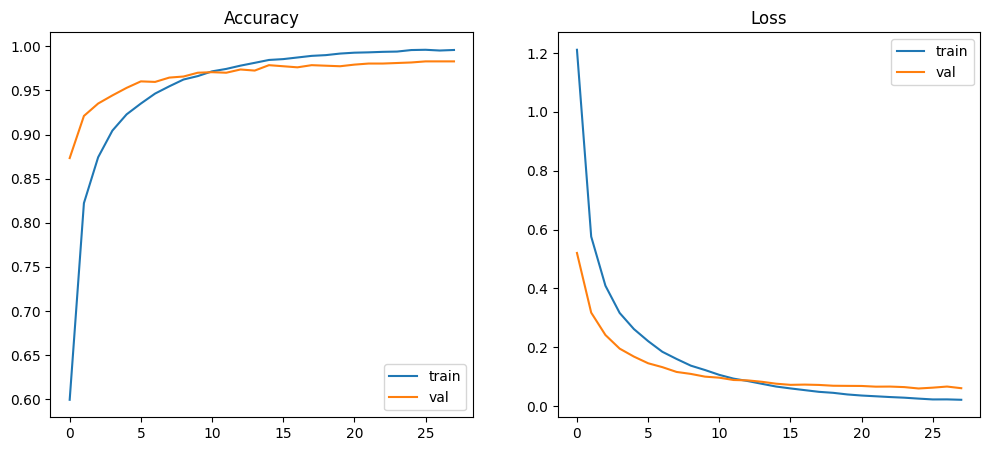

In [17]:
# ===============================
# 6. Plot Accuracy & Loss
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [18]:
# ===============================
# 7. Evaluation on Test Set
# ===============================
y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━

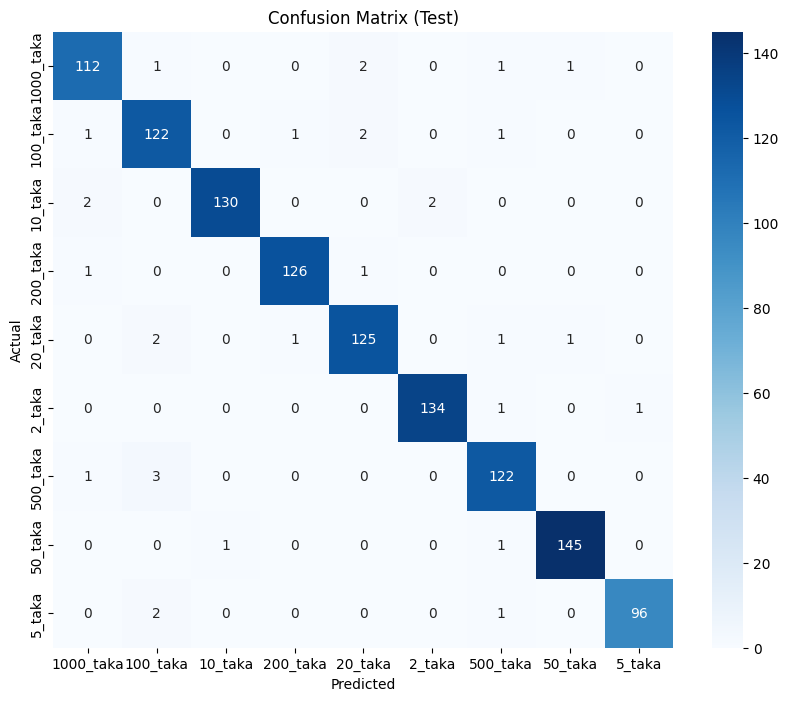

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test)')
plt.show()

In [20]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   1000_taka       0.96      0.96      0.96       117
    100_taka       0.94      0.96      0.95       127
     10_taka       0.99      0.97      0.98       134
    200_taka       0.98      0.98      0.98       128
     20_taka       0.96      0.96      0.96       130
      2_taka       0.99      0.99      0.99       136
    500_taka       0.95      0.97      0.96       126
     50_taka       0.99      0.99      0.99       147
      5_taka       0.99      0.97      0.98        99

    accuracy                           0.97      1144
   macro avg       0.97      0.97      0.97      1144
weighted avg       0.97      0.97      0.97      1144

